# Análisis exploratorio

In [1]:
import sys, os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import pandas as pd
import matplotlib.pyplot as plt

from data import download_data, make_features, FEATURE_NAMES

pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


## Cargar datos

In [2]:
df = download_data()
print("Filas:", len(df))
df.head()

Filas: 2515


,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02 00:00:00-05:00,24.648440,24.659504,23.754466,24.192602,212818400
2015-01-05 00:00:00-05:00,23.962469,24.042131,23.325182,23.511057,257142000
2015-01-06 00:00:00-05:00,23.575228,23.772167,23.152581,23.513269,263188400
2015-01-07 00:00:00-05:00,23.721278,23.942559,23.610638,23.842983,160423600
2015-01-08 00:00:00-05:00,24.170475,24.816614,24.053195,24.759081,237458000


In [3]:
df.describe()

,Open,High,Low,Close,Volume
count,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03
mean,93.535693,94.532238,92.611390,93.623190,1.171162e+08
std,65.177411,65.850856,64.573238,65.259577,6.839222e+07
min,20.488463,20.868638,20.367814,20.565868,2.323470e+07
25%,35.168903,35.540961,34.779575,35.138050,7.108655e+07
50%,64.013109,64.603174,63.447183,64.254364,1.003845e+08
75%,149.723870,151.665570,147.929012,149.941132,1.426222e+08
max,256.550862,258.448740,255.994420,257.375580,6.488252e+08


## Precio en el tiempo

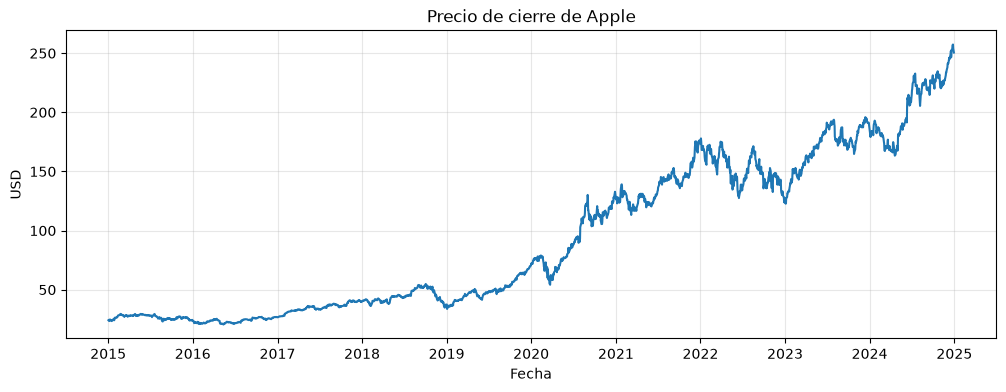

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["Close"])
plt.title("Precio de cierre de Apple")
plt.xlabel("Fecha")
plt.ylabel("USD")
plt.grid(True, alpha=0.3)
plt.show()

## Balance de clases

target
1    0.531651
0    0.468349
Name: proportion, dtype: float64


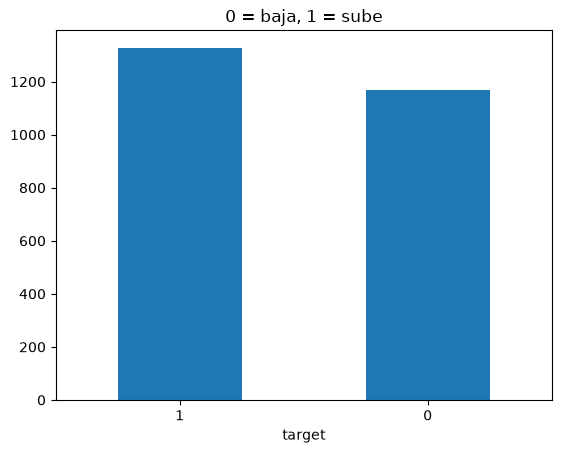

In [5]:
X, y, feats = make_features(df)
print(y.value_counts(normalize=True))

y.value_counts().plot(kind="bar")
plt.title("0 = baja, 1 = sube")
plt.xticks(rotation=0)
plt.show()

## Features

In [6]:
print(FEATURE_NAMES)
X.describe()

['return', 'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5', 'price_to_ma_5', 'price_to_ma_10', 'price_to_ma_20', 'volatility_5', 'volatility_10', 'volume_change', 'rsi_14']


,return,return_lag_1,return_lag_2,return_lag_3,return_lag_5,price_to_ma_5,price_to_ma_10,price_to_ma_20,volatility_5,volatility_10,volume_change,rsi_14
count,2496.000000,2496.000000,2496.000000,2496.000000,2496.000000,2496.000000,2496.000000,2496.000000,2496.000000,2496.000000,2496.000000,2496.000000
mean,0.001063,0.001081,0.001109,0.001094,0.001090,1.001895,1.004338,1.009274,0.015253,0.015848,0.048851,55.802199
std,0.017878,0.017886,0.017918,0.017933,0.017931,0.018594,0.028219,0.042366,0.009952,0.008635,0.353639,17.884406
min,-0.128647,-0.128647,-0.128647,-0.128647,-0.128647,0.909487,0.874606,0.831971,0.001389,0.003596,-0.830093,3.180057
25%,-0.007324,-0.007312,-0.007289,-0.007312,-0.007312,0.992214,0.988617,0.983707,0.008516,0.010196,-0.175053,42.712869
50%,0.000970,0.000994,0.001001,0.000994,0.000994,1.002734,1.005607,1.013312,0.012829,0.013926,-0.016266,56.668985
75%,0.010124,0.010141,0.010148,0.010148,0.010141,1.012705,1.022446,1.037156,0.019013,0.019431,0.194417,69.300691
max,0.119809,0.119809,0.119809,0.119809,0.119809,1.094217,1.118199,1.147493,0.107310,0.080056,3.771993,96.163034


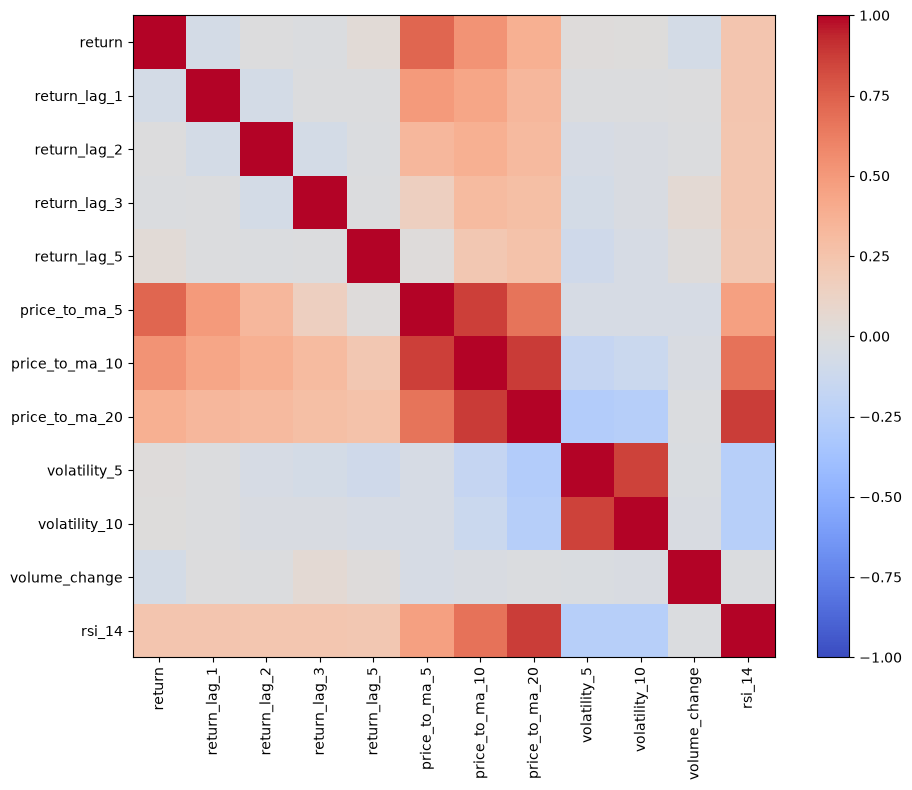

In [7]:
corr = X.corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.tight_layout()
plt.show()

## Observaciones


## Observaciones

- Balance de clases: el target está casi balanceado, con ~53% de días en que
  el precio sube (clase 1) y ~47% en que baja (clase 0). El desbalance es leve, así
  que no se requieren técnicas de balanceo. El baseline a superar es la clase
  mayoritaria (~0.53 de accuracy): cualquier modelo útil debe mejorar ese valor.

- Precio en el tiempo: Apple muestra una tendencia alcista clara entre 2015 y
  2025, con caídas puntuales (2020, 2022). Sin embargo, la dirección diaria es muy
  ruidosa, lo que anticipa que predecir el movimiento día a día es difícil pese a la
  tendencia de fondo.

- Correlaciones entre features:**
  - Las features de precio relativo a media móvil (price_to_ma_5/10/20) están
    fuertemente correlacionadas entre sí, lo que indica redundancia: las tres
    capturan información similar en ventanas distintas.
  - Las volatilidades (volatility_5 y volatility_10) también correlacionan entre sí.
  - Los retornos rezagados (return_lag_*) tienen correlación baja con el resto, lo
    que sugiere que los retornos pasados aportan poca señal predictiva por sí solos,
    consistente con la dificultad de predecir mercados.
  - No se observan correlaciones extremas entre features distintas, por lo que se
    conservan las 12 features para el modelado, teniendo en cuenta la redundancia
    detectada como posible punto de mejora (selección de features) más adelante.

- Implicación para el modelado: dado el balance casi parejo y la baja señal de
  las features, es esperable obtener métricas cercanas al azar (accuracy ~0.50–0.55).
  El criterio de éxito no será "ganarle al mercado", sino construir un pipeline
  correcto y comparar honestamente los modelos contra el baseline.